# 06 · Evaluation and error analysis

**Single responsibility:** choose the threshold on validation, lock it, evaluate once on test, and examine calibration and failure slices

Run after the preceding numbered notebook unless the inputs already exist. Every generated artifact is written outside the notebook so this stage is reproducible.


In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs/base.yaml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from vww_esp32.config import load_config, resolve_paths, seed_everything

config, ROOT = load_config(ROOT / 'configs/base.yaml')
paths = resolve_paths(config, ROOT)
seed_everything(config['project']['seed'])
ROOT


PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32')

In [2]:
import pandas as pd
import tensorflow as tf
from vww_esp32.preprocessing import make_dataset, split_manifest
from vww_esp32.evaluation import collect_predictions, select_threshold, classification_metrics, expected_calibration_error, save_metrics

manifest = pd.read_csv(paths['processed'] / 'manifest.csv')
splits = split_manifest(manifest)
image_size = tuple(config['preprocessing']['image_size'])
model = tf.keras.models.load_model(paths['artifacts'] / 'checkpoints' / 'best.keras')
val_ds = make_dataset(splits['val'], image_size, config['preprocessing']['batch_size'])
y_val, p_val = collect_predictions(model, val_ds)

2026-09-14 17:25:43.384918: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


In [3]:
choice = select_threshold(y_val, p_val, objective=config['evaluation']['threshold_objective'], minimum_recall=config['evaluation']['minimum_recall'], false_positive_cost=config['evaluation']['false_positive_cost'], false_negative_cost=config['evaluation']['false_negative_cost'])
choice

{'threshold': 0.34,
 'f1': 0.719290465631929,
 'recall': 0.8200202224469161,
 'cost': 811.0}

The threshold is now locked. The following cell is the first use of the held-out test labels.

In [4]:
test_ds = make_dataset(splits['test'], image_size, config['preprocessing']['batch_size'])
y_test, p_test = collect_predictions(model, test_ds)
test_metrics = classification_metrics(y_test, p_test, choice['threshold'])
test_metrics['expected_calibration_error_10_bins'] = expected_calibration_error(y_test, p_test, bins=10)
save_metrics(test_metrics, paths['artifacts'] / 'reports' / 'test_metrics.json')
test_metrics

 3/32 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step 

2026-09-14 17:25:51.195432: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


{'samples': 2000,
 'threshold': 0.34,
 'accuracy': 0.691,
 'precision': 0.644852354349561,
 'recall': 0.8236493374108053,
 'f1': 0.7233661593554163,
 'roc_auc': 0.8009401393903199,
 'pr_auc': 0.8034297147139705,
 'specificity': 0.563297350343474,
 'confusion_matrix': [[574, 445], [173, 808]],
 'positive_prevalence': 0.4905,
 'predicted_positive_rate': 0.6265,
 'expected_calibration_error_10_bins': 0.023007355242967605}

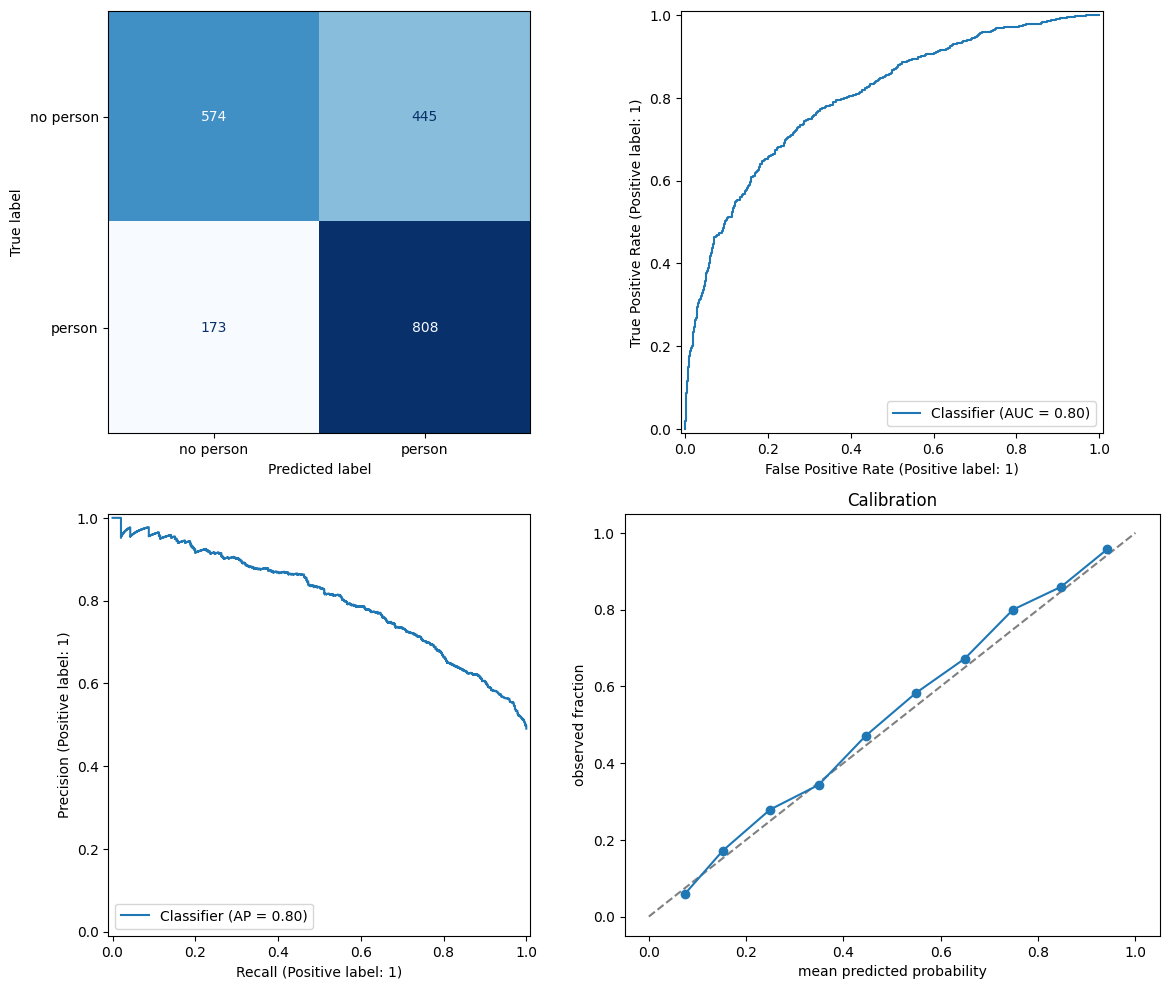

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from vww_esp32.evaluation import calibration_points

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_test, p_test >= choice['threshold'], display_labels=['no person', 'person'], cmap='Blues', ax=axes[0, 0], colorbar=False)
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[0, 1])
PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[1, 0])
predicted, observed = calibration_points(y_test, p_test)
axes[1, 1].plot([0, 1], [0, 1], '--', color='gray')
axes[1, 1].plot(predicted, observed, marker='o')
axes[1, 1].set(xlabel='mean predicted probability', ylabel='observed fraction', title='Calibration')
plt.tight_layout()
fig.savefig(paths['artifacts'] / 'figures' / 'test_evaluation.png', dpi=160, bbox_inches='tight')

In [6]:
predictions = splits['test'].copy()
predictions['probability'] = p_test
predictions['prediction'] = (p_test >= choice['threshold']).astype(int)
predictions['correct'] = predictions.label == predictions.prediction
predictions.to_csv(paths['artifacts'] / 'reports' / 'test_predictions.csv', index=False)
slices = predictions.assign(brightness_bin=pd.qcut(predictions.brightness, 4, duplicates='drop'), scale_bin=pd.cut(predictions.max_person_area_fraction, [-1, .01, .05, .15, 1])).groupby(['brightness_bin', 'label'], observed=True).correct.agg(['count', 'mean'])
slices

count      mean
brightness_bin     label                 
(23.052, 96.511]   0        250  0.476000
                   1        250  0.844000
(96.511, 114.0]    0        246  0.565041
                   1        254  0.830709
(114.0, 132.317]   0        263  0.577947
                   1        237  0.789030
(132.317, 225.917] 0        260  0.630769
                   1        240  0.829167

In [7]:
import numpy as np

errors = predictions[~predictions.correct].copy()
errors['confidence'] = np.where(errors.prediction == 1, errors.probability, 1-errors.probability)
errors.sort_values('confidence', ascending=False)[['image_path', 'label', 'probability', 'max_person_area_fraction', 'brightness', 'contrast']].head(20)

,image_path,label,probability,max_person_area_fraction,brightness,contrast
861,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,0,0.969602,0.000000,137.534180,33.183363
1384,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,0,0.954735,0.000000,97.469727,60.703276
1959,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,1,0.069638,0.013286,120.435547,44.270936
613,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,0,0.930095,0.000000,131.935547,42.172379
1918,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,0,0.930018,0.004935,113.864258,49.309253
1439,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,1,0.070492,0.059679,110.281250,43.118489
1450,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,0,0.916508,0.000000,142.092773,78.347297
1276,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,0,0.914924,0.000000,93.667969,71.269262
132,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,1,0.086660,0.038654,116.040039,31.551257
894,/Volumes/VM_SSD/Machine Learning/visual-wake-w...,1,0.090970,0.005459,98.564453,53.948758
